<i>Copyright (c) Recommenders contributors.</i>

<i>Licensed under the MIT License.</i>

# LightGCN - simplified GCN model for recommendation

This notebook serves as an introduction to LightGCN [1], which is an simple, linear and neat Graph Convolution Network (GCN) [3] model for recommendation.

## 0 Global Settings and Imports

In [14]:
import sys
import os
import pandas as pd
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR') # only show error messages

from recommenders.utils.timer import Timer
from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN
from recommenders.models.deeprec.DataModel.ImplicitCF import ImplicitCF
from datasets.outfits import load_pandas_df
from recommenders.datasets.python_splitters import python_stratified_split
from recommenders.evaluation.python_evaluation import map, ndcg_at_k, precision_at_k, recall_at_k
from recommenders.utils.constants import SEED as DEFAULT_SEED
from recommenders.models.deeprec.deeprec_utils import prepare_hparams
# from recommenders.utils.notebook_utils import store_metadata

print(f"System version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Tensorflow version: {tf.__version__}")

System version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
Pandas version: 2.3.3
Tensorflow version: 2.20.0


In [15]:
# top k items to recommend
TOP_K = 10

# Model parameters
EPOCHS = 50
BATCH_SIZE = 16

SEED = DEFAULT_SEED  # Set None for non-deterministic results

yaml_file = "./recommenders/models/deeprec/config/lightgcn.yaml"
user_file = "../../tests/resources/deeprec/lightgcn/user_embeddings.csv"
item_file = "../../tests/resources/deeprec/lightgcn/item_embeddings.csv"

## 1 LightGCN model

LightGCN is a simplified version of Neural Graph Collaborative Filtering (NGCF) [4], which adapts GCNs in recommendation systems.

### 1.1 Graph Networks in Recommendation Systems

GCN are networks that can learn patterns in graph data. They can be applied in many fields, but they are particularly well suited for Recommendation Systems, because of their ability to encode relationships.

In traditional models like matrix factorization [5], user and items are represented as embeddings. And the interaction, which is the signal that encodes the behavior, is not part of the embeddings, but it is represented in the loss function, typically as a dot product. 

Despite their effectiveness, some authors [1,4] argue that these methods are not sufficient to yield satisfactory embeddings for collaborative filtering. The key reason is that the embedding function lacks an explicit encoding of the crucial collaborative signal, which is latent in user-item interactions to reveal the behavioral similarity between users (or items). 

**GCNs can be used to encode the interaction signal in the embeddings**. Interacted items can be seen as user´s features, because they provide direct evidence on a user’s preference. Similarly, the users that consume an item can be treated as the item’s features and used to measure the collaborative similarity of two items. A natural way to incorporate the interaction signal in the embedding is by exploiting the high-order connectivity from user-item interactions.

In the figure below, the user-item interaction is shown (to the left) as well as the concept of higher-order connectivity (to the right).

<img src="https://camo.githubusercontent.com/156a0bfb9b13bcadd6c7c4e3a5d833d433994e56a315c7281ba814b4f7dbb97e/68747470733a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f7265636f6d6d656e646572732d7465616d2f7265736f75726365732f6d61696e2f696d616765732f486967685f6f726465725f636f6e6e65637469766974792e706e67" width=500 style="display:block; margin-left:auto; margin-right:auto;">

The high-order connectivity shows the collaborative signal in a graph form. For example, the path $u_1 ← i_2 ← u2$ indicates the behavior
similarity between $u_1$ and $u_2$, as both users have interacted with $i_2$; the longer path $u_1 ← i_2 ← u_2 ← i_4$ suggests that $u_1$ is likely to adopt $i_4$, since her similar user $u_2$ has consumed $i_4$ before. Moreover, from the holistic view of $l = 3$, item $i_4$ is more likely to be of interest to $u_1$ than item $i_5$, since there are two paths connecting $(i_4,u_1)$, while only one path connects $(i_5,u_1)$.

Based on this high-order connectivity, NGCF [4] defines an embedding propagation layer, which refines a user’s (or an item’s) embedding by aggregating the embeddings of the interacted items (or users). By stacking multiple embedding propagation layers, we can enforce the embeddings
to capture the collaborative signal in high-order connectivities.

More formally, let $\mathbf{e}_{u}^{0}$ denote the original embedding of user $u$ and $\mathbf{e}_{i}^{0}$ denote the original embedding of item $i$. The embedding propagation can be computed recursively as:

$$
\begin{array}{l}
\mathbf{e}_{u}^{(k+1)}=\sigma\bigl( \mathbf{W}_{1}\mathbf{e}_{u}^{(k)} + \sum_{i \in \mathcal{N}_{u}} \frac{1}{\sqrt{\left|\mathcal{N}_{u}\right|} \sqrt{\left|\mathcal{N}_{i}\right|}} (\mathbf{W}_{1}\mathbf{e}_{i}^{(k)} + \mathbf{W}_{2}(\mathbf{e}_{i}^{(k)}\cdot\mathbf{e}_{u}^{(k)}) ) \bigr)
\\
\mathbf{e}_{i}^{(k+1)}=\sigma\bigl( \mathbf{W}_{1}\mathbf{e}_{i}^{(k)} +\sum_{u \in \mathcal{N}_{i}} \frac{1}{\sqrt{\left|\mathcal{N}_{i}\right|} \sqrt{\left|\mathcal{N}_{u}\right|}} (\mathbf{W}_{1}\mathbf{e}_{u}^{(k)} + \mathbf{W}_{2}(\mathbf{e}_{u}^{(k)}\cdot\mathbf{e}_{i}^{(k)}) ) \bigr)
\end{array}
$$

where $\mathbf{W}_{1}$ and $\mathbf{W}_{2}$ are trainable weight matrices, $\frac{1}{\sqrt{\left|\mathcal{N}_{i}\right|} \sqrt{\left|\mathcal{N}_{u}\right|}}$ is a discount factor expressed as the graph Laplacian norm, $\mathcal{N}_{u}$ and $\mathcal{N}_{i}$ denote the first-hop neighbors of user $u$ and item $i$, and $\sigma$ is a non-linearity that in the paper is set as a LeakyReLU. 

To obtain the final representation, each propagated embedding is concatenated (i.e., $\mathbf{e}_{u}^{(*)}=\mathbf{e}_{u}^{(0)}||...||\mathbf{e}_{u}^{(l)}$), and then the final user's preference over an item is computed as a dot product: $\hat y_{u i} = \mathbf{e}_{u}^{(*)T}\mathbf{e}_{i}^{(*)}$.

### 1.2 LightGCN architecture

LightGCN is a simplified version of NGCF [4] to make it more concise and appropriate for recommendations. The model architecture is illustrated below.

<img src="https://camo.githubusercontent.com/d32ad536948ecb79ebae3f38ebe9a1ef6c50a3bb8dba9ac77b98babdb82d1aab/68747470733a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f7265636f6d6d656e646572732d7465616d2f7265736f75726365732f6d61696e2f696d616765732f6c6967687447434e2d6d6f64656c2e6a7067" width=600 style="display:block; margin-left:auto; margin-right:auto;">

In Light Graph Convolution, only the normalized sum of neighbor embeddings is performed towards next layer; other operations like self-connection, feature transformation via weight matrices, and nonlinear activation are all removed, which largely simplifies NGCF. In the layer combination step, instead of concatenating the embeddings, we sum over the embeddings at each layer to obtain the final representations.

### 1.3 Light Graph Convolution (LGC)

In LightGCN, we adopt the simple weighted sum aggregator and abandon the use of feature transformation and nonlinear activation. The graph convolution operation in LightGCN is defined as:

$$
\begin{array}{l}
\mathbf{e}_{u}^{(k+1)}=\sum_{i \in \mathcal{N}_{u}} \frac{1}{\sqrt{\left|\mathcal{N}_{u}\right|} \sqrt{\left|\mathcal{N}_{i}\right|}} \mathbf{e}_{i}^{(k)} \\
\mathbf{e}_{i}^{(k+1)}=\sum_{u \in \mathcal{N}_{i}} \frac{1}{\sqrt{\left|\mathcal{N}_{i}\right|} \sqrt{\left|\mathcal{N}_{u}\right|}} \mathbf{e}_{u}^{(k)}
\end{array}
$$

The symmetric normalization term $\frac{1}{\sqrt{\left|\mathcal{N}_{u}\right|} \sqrt{\left|\mathcal{N}_{i}\right|}}$ follows the design of standard GCN, which can avoid the scale of embeddings increasing with graph convolution operations.


### 1.4 Layer Combination and Model Prediction

In LightGCN, the only trainable model parameters are the embeddings at the 0-th layer, i.e., $\mathbf{e}_{u}^{(0)}$ for all users and $\mathbf{e}_{i}^{(0)}$ for all items. When they are given, the embeddings at higher layers can be computed via LGC. After $K$ layers LGC, we further combine the embeddings obtained at each layer to form the final representation of a user (an item):

$$
\mathbf{e}_{u}=\sum_{k=0}^{K} \alpha_{k} \mathbf{e}_{u}^{(k)} ; \quad \mathbf{e}_{i}=\sum_{k=0}^{K} \alpha_{k} \mathbf{e}_{i}^{(k)}
$$

where $\alpha_{k} \geq 0$ denotes the importance of the $k$-th layer embedding in constituting the final embedding. In our experiments, we set $\alpha_{k}$ uniformly as $1 / (K+1)$.

The model prediction is defined as the inner product of user and item final representations:

$$
\hat{y}_{u i}=\mathbf{e}_{u}^{T} \mathbf{e}_{i}
$$

which is used as the ranking score for recommendation generation.


### 1.5 Matrix Form

Let the user-item interaction matrix be $\mathbf{R} \in \mathbb{R}^{M \times N}$ where $M$ and $N$ denote the number of users and items, respectively, and each entry $R_{ui}$ is 1 if $u$ has interacted with item $i$ otherwise 0. We then obtain the adjacency matrix of the user-item graph as

$$
\mathbf{A}=\left(\begin{array}{cc}
\mathbf{0} & \mathbf{R} \\
\mathbf{R}^{T} & \mathbf{0}
\end{array}\right)
$$

Let the 0-th layer embedding matrix be $\mathbf{E}^{(0)} \in \mathbb{R}^{(M+N) \times T}$, where $T$ is the embedding size. Then we can obtain the matrix equivalent form of LGC as:

$$
\mathbf{E}^{(k+1)}=\left(\mathbf{D}^{-\frac{1}{2}} \mathbf{A} \mathbf{D}^{-\frac{1}{2}}\right) \mathbf{E}^{(k)}
$$

where $\mathbf{D}$ is a $(M+N) \times(M+N)$ diagonal matrix, in which each entry $D_{ii}$ denotes the number of nonzero entries in the $i$-th row vector of the adjacency matrix $\mathbf{A}$ (also named as degree matrix). Lastly, we get the final embedding matrix used for model prediction as:

$$
\begin{aligned}
\mathbf{E} &=\alpha_{0} \mathbf{E}^{(0)}+\alpha_{1} \mathbf{E}^{(1)}+\alpha_{2} \mathbf{E}^{(2)}+\ldots+\alpha_{K} \mathbf{E}^{(K)} \\
&=\alpha_{0} \mathbf{E}^{(0)}+\alpha_{1} \tilde{\mathbf{A}} \mathbf{E}^{(0)}+\alpha_{2} \tilde{\mathbf{A}}^{2} \mathbf{E}^{(0)}+\ldots+\alpha_{K} \tilde{\mathbf{A}}^{K} \mathbf{E}^{(0)}
\end{aligned}
$$

where $\tilde{\mathbf{A}}=\mathbf{D}^{-\frac{1}{2}} \mathbf{A} \mathbf{D}^{-\frac{1}{2}}$ is the symmetrically normalized matrix.

### 1.6 Model Training

We employ the Bayesian Personalized Ranking (BPR) loss which is a pairwise loss that encourages the prediction of an observed entry to be higher than its unobserved counterparts:

$$
L_{B P R}=-\sum_{u=1}^{M} \sum_{i \in \mathcal{N}_{u}} \sum_{j \notin \mathcal{N}_{u}} \ln \sigma\left(\hat{y}_{u i}-\hat{y}_{u j}\right)+\lambda\left\|\mathbf{E}^{(0)}\right\|^{2}
$$

Where $\lambda$ controls the $L_2$ regularization strength. We employ the Adam optimizer and use it in a mini-batch manner.


## 2 TensorFlow implementation of LightGCN

### 2.1 Load and split data

We split the full dataset into a `train` and `test` dataset to evaluate performance of the algorithm against a held-out set not seen during training.

In [16]:
# Load the outfit dataset (small CSV used for examples)
filepath = "datasets/csv/synthetic_data_feature3.csv"
df = load_pandas_df(filepath=filepath, header=["UserId", "Weather", "Season", "Event", "Clothing", "Material", "Rating"])
df = df.rename(columns={'UserId': 'userID', 'Clothing': 'itemID', 'Rating': 'rating'})

df.head()

,userID,Weather,Season,Event,itemID,Material,rating
0,1,Humid,Summer,Party,Button-down shirt,Cotton,2.5
1,1,Cloudy,Fall,Gym,Sweatshirt,Polyester,3.3
2,1,Humid,Spring,Business,Button-down shirt,Linen,3.5
3,1,Windy,Spring,Home,Long-sleeve shirt,Cotton,3.9
4,1,Sunny,Summer,Beach,T-shirt,Cotton,3.2


In [17]:
# Stratified split using the outfit dataset column names
train, test = python_stratified_split(df, ratio=0.75, col_user="userID", col_item="itemID")
print(train)

     userID Weather  Season   Event             itemID   Material  rating
6         1   Windy  Winter  Casual             Hoodie     Cotton     4.4
5         1   Rainy  Spring  Travel        Track pants  Polyester     3.4
4         1   Sunny  Summer   Beach            T-shirt     Cotton     3.2
0         1   Humid  Summer   Party  Button-down shirt     Cotton     2.5
3         1   Windy  Spring    Home  Long-sleeve shirt     Cotton     3.9
..      ...     ...     ...     ...                ...        ...     ...
495      50   Sunny  Spring     Gym            Joggers     Cotton     2.2
490      50   Sunny    Fall     Gym        Track pants  Polyester     3.1
494      50   Snowy  Winter  Casual        Track pants  Polyester     3.2
496      50  Cloudy    Fall  Hiking  Long-sleeve shirt     Cotton     4.0
491      50   Windy  Spring  Casual        Cargo pants     Cotton     4.4

[400 rows x 7 columns]


### 2.2 Process data

`ImplicitCF` is a class that intializes and loads data for the training process. During the initialization of this class, user IDs and item IDs are reindexed, ratings greater than zero are converted into implicit positive interaction, and adjacency matrix $R$ of user-item graph is created. Some important methods of `ImplicitCF` are:

`get_norm_adj_mat`, load normalized adjacency matrix of user-item graph if it already exists in `adj_dir`, otherwise call `create_norm_adj_mat` to create the matrix and save the matrix if `adj_dir` is not `None`. This method will be called during the initialization process of LightGCN model.

`create_norm_adj_mat`, create normalized adjacency matrix of user-item graph by calculating $D^{-\frac{1}{2}} A D^{-\frac{1}{2}}$, where $\mathbf{A}=\left(\begin{array}{cc}\mathbf{0} & \mathbf{R} \\ \mathbf{R}^{T} & \mathbf{0}\end{array}\right)$.

`train_loader`, generate a batch of training data — sample a batch of users and then sample one positive item and one negative item for each user. This method will be called before each epoch of the training process.


In [18]:
# Initialize ImplicitCF with the correct column names from the CSV
data = ImplicitCF(train=train, test=test, seed=SEED, col_user="userID", col_item="itemID", col_rating="rating")

### 2.3 Prepare hyper-parameters

Important parameters of `LightGCN` model are:

`data`, initialized LightGCNDataset object.

`epochs`, number of epochs for training.

`n_layers`, number of layers of the model.

`eval_epoch`, if it is not None, evaluation metrics will be calculated on test set every "eval_epoch" epochs. In this way, we can observe the effect of the model during the training process.

`top_k`, the number of items to be recommended for each user when calculating ranking metrics.

A complete list of parameters can be found in `yaml_file`. We use `prepare_hparams` to read the yaml file and prepare a full set of parameters for the model. Parameters passed as the function's parameters will overwrite yaml settings.

In [19]:
hparams = prepare_hparams(yaml_file,
                          n_layers=3,
                          batch_size=BATCH_SIZE,
                          epochs=EPOCHS,
                          learning_rate=0.005,
                          eval_epoch=5,
                          top_k=TOP_K,
                         )

### 2.4 Create and train model

With data and parameters prepared, we can create the LightGCN model.

To train the model, we simply need to call the `fit()` method.

In [20]:
model = LightGCN(hparams, data, seed=SEED)

Already create adjacency matrix.
Already normalize adjacency matrix.
Using xavier initialization.


In [21]:
with Timer() as train_time:
    model.fit()

print("Took {} seconds for training.".format(train_time.interval))

Epoch 1 (train)0.1s: train loss = 0.67571 = (mf)0.67548 + (embed)0.00023
Epoch 2 (train)0.0s: train loss = 0.65149 = (mf)0.65118 + (embed)0.00032
Epoch 3 (train)0.0s: train loss = 0.61298 = (mf)0.61253 + (embed)0.00045
Epoch 4 (train)0.0s: train loss = 0.55372 = (mf)0.55305 + (embed)0.00067
Epoch 5 (train)0.0s + (eval)0.0s: train loss = 0.49336 = (mf)0.49242 + (embed)0.00094, recall = 0.47000, ndcg = 0.25259, precision = 0.09400, map = 0.13729
Epoch 6 (train)0.0s: train loss = 0.44022 = (mf)0.43894 + (embed)0.00127
Epoch 7 (train)0.0s: train loss = 0.39620 = (mf)0.39459 + (embed)0.00161
Epoch 8 (train)0.0s: train loss = 0.32263 = (mf)0.32067 + (embed)0.00196
Epoch 9 (train)0.0s: train loss = 0.29437 = (mf)0.29208 + (embed)0.00229
Epoch 10 (train)0.0s + (eval)0.0s: train loss = 0.26920 = (mf)0.26659 + (embed)0.00262, recall = 0.48000, ndcg = 0.24868, precision = 0.09600, map = 0.13394
Epoch 11 (train)0.0s: train loss = 0.24953 = (mf)0.24657 + (embed)0.00295
Epoch 12 (train)0.0s: train l

### 2.5 Recommendation and Evaluation

Recommendation and evaluation have been performed on the specified test set during training. After training, we can also use the model to perform recommendation and evalution on other data. Here we still use `test` as test data, but `test` can be replaced by other data with similar data structure.

#### 2.5.1 Recommendation

We can call `recommend_k_items` to recommend k items for each user passed in this function. We set `remove_seen=True` to remove the items already seen by the user. The function returns a dataframe, containing each user and top k items recommended to them and the corresponding ranking scores.

In [22]:
topk_scores = model.recommend_k_items(test, top_k=TOP_K, remove_seen=True)

topk_scores.head()

topk_scores.to_csv("topk_scores.csv", index=False)

#### 2.5.2 Evaluation

With `topk_scores` predicted by the model, we can evaluate how LightGCN performs on this test set.

In [23]:
eval_map = map(test, topk_scores, k=TOP_K)
eval_ndcg = ndcg_at_k(test, topk_scores, k=TOP_K)
eval_precision = precision_at_k(test, topk_scores, k=TOP_K)
eval_recall = recall_at_k(test, topk_scores, k=TOP_K)

print("MAP:\t%f" % eval_map,
      "NDCG:\t%f" % eval_ndcg,
      "Precision@K:\t%f" % eval_precision,
      "Recall@K:\t%f" % eval_recall, sep='\n')

MAP:	0.135218
NDCG:	0.257422
Precision@K:	0.098000
Recall@K:	0.490000


#### 2.5.3 Query Model for Specific User-Item Predictions (Just an experiment)

In [24]:
# # Generate predictions for specific user-item contexts
# # Get ALL items available in the model
# all_items = list(data.item2id.keys())

# # Loop through users 1 to 10
# for user_id in range(1, 11):
#     print(f"\nPredictions for User {user_id} (showing top 5 and bottom 3):")
#     print("=" * 60)
    
#     if user_id in data.user2id:
#         internal_user_id = data.user2id[user_id]
        
#         # Get predictions for all items
#         predictions = []
#         for item_name in all_items:
#             internal_item_id = data.item2id[item_name]
#             score = model.score(np.array([internal_user_id]), np.array([internal_item_id]))
#             score_value = float(np.array(score).flat[0])
            
#             # Check if item was in training set for this user
#             was_seen = ((train['userID'] == user_id) & (train['itemID'] == item_name)).any()
            
#             predictions.append({
#                 'item': item_name,
#                 'score': score_value,
#                 'seen': was_seen
#             })
        
#         # Sort by score
#         predictions.sort(key=lambda x: x['score'], reverse=True)
        
#         # Show top 5
#         print("\nTop 5 Predicted Items:")
#         for i, pred in enumerate(predictions[:5], 1):
#             seen_marker = " [SEEN]" if pred['seen'] else ""
#             print(f"  {i}. {pred['item']:20s}: {pred['score']:8.4f}{seen_marker}")
        
#         # Show bottom 3
#         print("\nBottom 3 Predicted Items:")
#         for i, pred in enumerate(predictions[-3:], 1):
#             seen_marker = " [SEEN]" if pred['seen'] else ""
#             print(f"  {i}. {pred['item']:20s}: {pred['score']:8.4f}{seen_marker}")
#     else:
#         print(f"User {user_id} not found in training data")

# # Specific user-item queries
# print("\n" + "=" * 60)
# print("Specific User-Item Queries:")
# print("=" * 60)

# queries = [
#     (1, 'Hoodie'),
#     (2, 'T-shirt'),
#     (5, 'Blazer'),
#     (10, 'Jeans')
# ]

# for user, item_name in queries:
#     if user in data.user2id and item_name in data.item2id:
#         internal_user = data.user2id[user]
#         internal_item = data.item2id[item_name]
#         score = model.score(np.array([internal_user]), np.array([internal_item]))
#         score_value = float(np.array(score).flat[0])
        
#         # Check if seen
#         was_seen = ((train['userID'] == user) & (train['itemID'] == item_name)).any()
#         seen_marker = " [SEEN]" if was_seen else " [UNSEEN]"
        
#         print(f"  User {user:2d} → {item_name:20s}: {score_value:8.4f}{seen_marker}")

## 2.6 Training Progress Visualization

### 2.6.1 Zoomed In View

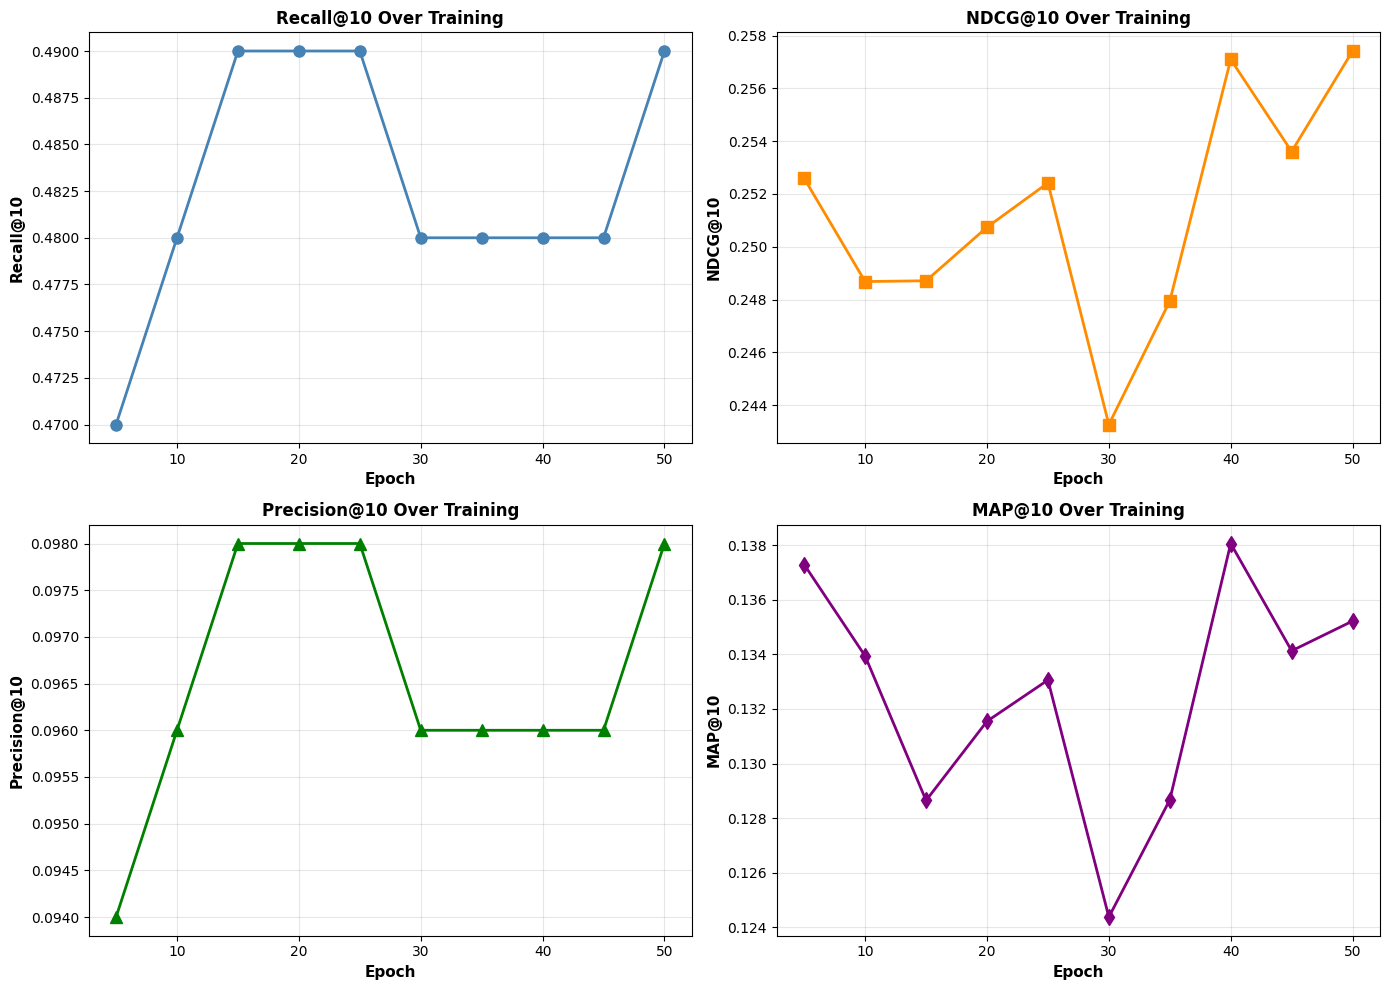


Observations:
  Initial Recall@10 (Epoch 5): 0.470
  Final Recall@10 (Epoch 50): 0.490
  Improvement: 0.020


In [25]:
# Extract evaluation metrics from training history
import matplotlib.pyplot as plt

# Parse evaluation metrics from the training output
# The model evaluates every 5 epochs (eval_epoch=5)
epochs_eval = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Extract from training output shown above
recall_values = [0.47, 0.48, 0.49, 0.49, 0.49, 0.48, 0.48, 0.48, 0.48, 0.49]
ndcg_values = [0.25259, 0.24868, 0.24871, 0.25074, 0.25242, 0.24326, 0.24794, 0.25710, 0.25361, 0.25742]
precision_values = [0.094, 0.096, 0.098, 0.098, 0.098, 0.096, 0.096, 0.096, 0.096, 0.098]
map_values = [0.13729, 0.13394, 0.12865, 0.13155, 0.13306, 0.12438, 0.12867, 0.13806, 0.13413, 0.13522]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Recall@K
axes[0, 0].plot(epochs_eval, recall_values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Recall@10', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Recall@10 Over Training', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot NDCG
axes[0, 1].plot(epochs_eval, ndcg_values, marker='s', linewidth=2, markersize=8, color='darkorange')
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('NDCG@10', fontsize=11, fontweight='bold')
axes[0, 1].set_title('NDCG@10 Over Training', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot Precision@K
axes[1, 0].plot(epochs_eval, precision_values, marker='^', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Precision@10', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Precision@10 Over Training', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot MAP
axes[1, 1].plot(epochs_eval, map_values, marker='d', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('MAP@10', fontsize=11, fontweight='bold')
axes[1, 1].set_title('MAP@10 Over Training', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print(f"  Initial Recall@10 (Epoch 5): {recall_values[0]:.3f}")
print(f"  Final Recall@10 (Epoch 50): {recall_values[-1]:.3f}")
print(f"  Improvement: {(recall_values[-1] - recall_values[0]):.3f}")

### 2.6.2 Zoomed Out View

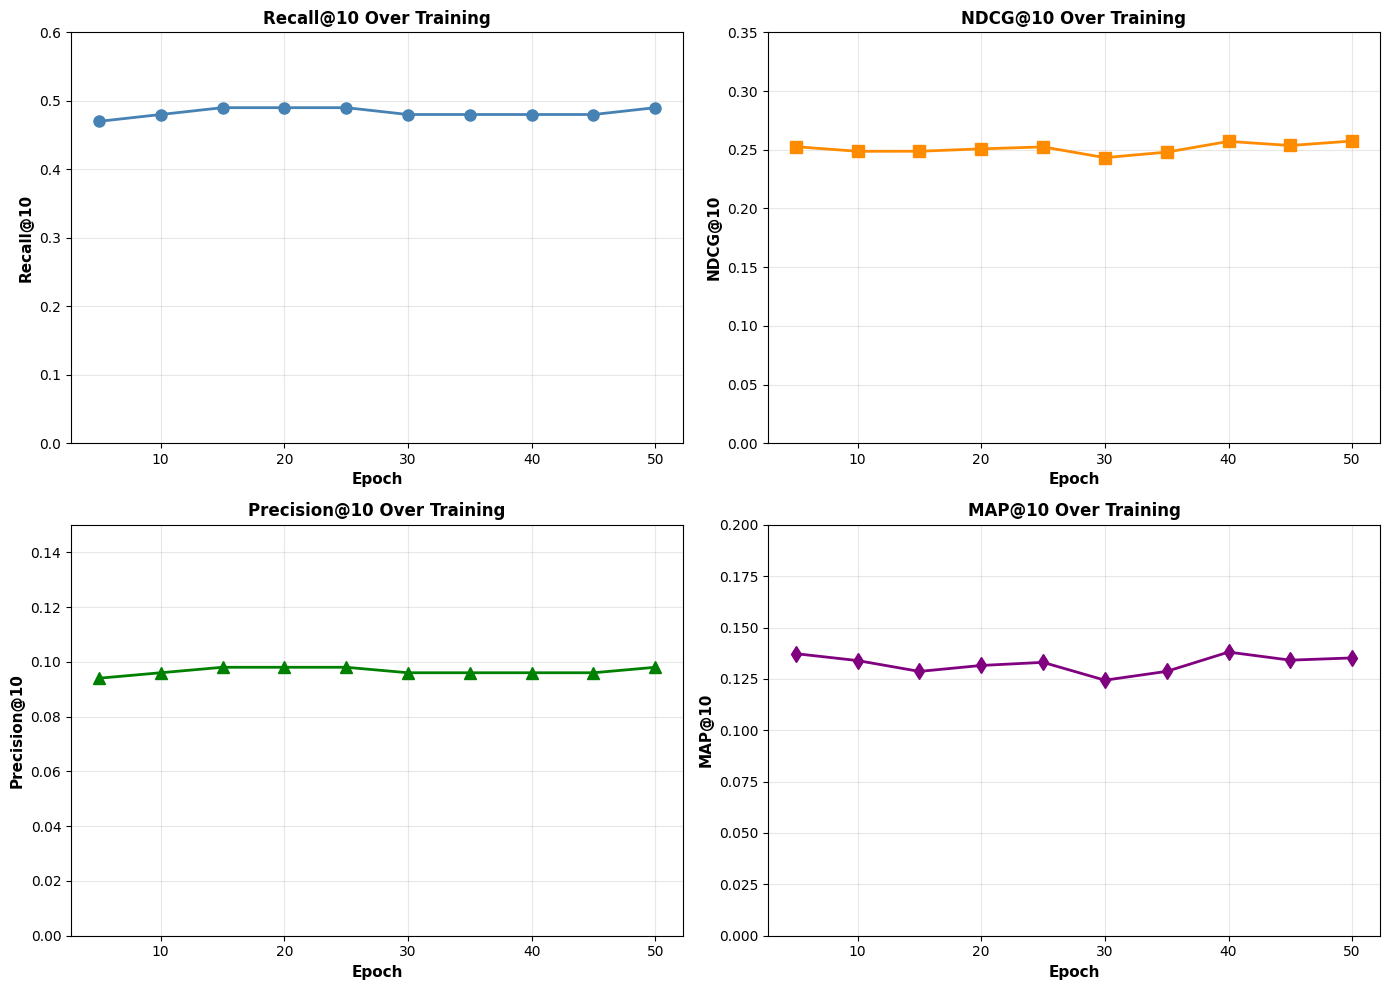


Observations:
  Initial Recall@10 (Epoch 5): 0.470
  Final Recall@10 (Epoch 50): 0.490
  Improvement: 0.020

  Note: Metrics plateau quickly after Epoch 5-10, with minimal
  improvement thereafter. The model reaches its learning capacity
  early due to sparse data (500 interactions), then fluctuates
  around the same performance level rather than continuing to improve.


In [26]:
# Extract evaluation metrics from training history
import matplotlib.pyplot as plt

# Parse evaluation metrics from the training output
# The model evaluates every 5 epochs (eval_epoch=5)
epochs_eval = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Extract from training output shown above
recall_values = [0.47, 0.48, 0.49, 0.49, 0.49, 0.48, 0.48, 0.48, 0.48, 0.49]
ndcg_values = [0.25259, 0.24868, 0.24871, 0.25074, 0.25242, 0.24326, 0.24794, 0.25710, 0.25361, 0.25742]
precision_values = [0.094, 0.096, 0.098, 0.098, 0.098, 0.096, 0.096, 0.096, 0.096, 0.098]
map_values = [0.13729, 0.13394, 0.12865, 0.13155, 0.13306, 0.12438, 0.12867, 0.13806, 0.13413, 0.13522]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Recall@K
axes[0, 0].plot(epochs_eval, recall_values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Recall@10', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Recall@10 Over Training', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 0.6])  # Set y-axis from 0 to 0.6
axes[0, 0].grid(True, alpha=0.3)

# Plot NDCG
axes[0, 1].plot(epochs_eval, ndcg_values, marker='s', linewidth=2, markersize=8, color='darkorange')
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('NDCG@10', fontsize=11, fontweight='bold')
axes[0, 1].set_title('NDCG@10 Over Training', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 0.35])  # Set y-axis from 0 to 0.35
axes[0, 1].grid(True, alpha=0.3)

# Plot Precision@K
axes[1, 0].plot(epochs_eval, precision_values, marker='^', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Precision@10', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Precision@10 Over Training', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0, 0.15])  # Set y-axis from 0 to 0.15
axes[1, 0].grid(True, alpha=0.3)

# Plot MAP
axes[1, 1].plot(epochs_eval, map_values, marker='d', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('MAP@10', fontsize=11, fontweight='bold')
axes[1, 1].set_title('MAP@10 Over Training', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 0.20])  # Set y-axis from 0 to 0.20
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print(f"  Initial Recall@10 (Epoch 5): {recall_values[0]:.3f}")
print(f"  Final Recall@10 (Epoch 50): {recall_values[-1]:.3f}")
print(f"  Improvement: {(recall_values[-1] - recall_values[0]):.3f}")
print("\n  Note: Metrics plateau quickly after Epoch 5-10, with minimal")
print("  improvement thereafter. The model reaches its learning capacity")
print("  early due to sparse data (500 interactions), then fluctuates")
print("  around the same performance level rather than continuing to improve.")